# LSTM Weather Forecasting — Benchmark Experiments

## Experiments Overview

| # | Experiment | Key Change |
|---|-----------|------------|
| 0 | **Baseline** | LSTM(32), 1 layer, lr=0.001, batch=256 |
| 1 | **Stacked LSTM** | 2 stacked LSTM layers (64 to 32) |
| 2 | **Larger Hidden Size** | LSTM(128) single layer |
| 3 | **Bidirectional LSTM** | BiLSTM(32) (reads sequence both ways) |
| 4 | **CNN + LSTM Hybrid** | Conv1D(64) feature extractor to LSTM(32) |

## 1. Setup & Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import keras
import time
import tensorflow as tf
import os
from zipfile import ZipFile
from google.colab import drive
from keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

drive.mount('/content/drive')
DRIVE_SAVE_DIR = '/content/drive/MyDrive/CMPE401/LSTM'
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

print('Keras version:', keras.__version__)
print('Models will be saved to:', DRIVE_SAVE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Keras version: 3.13.2
Models will be saved to: /content/drive/MyDrive/CMPE401/LSTM


## 2. Load & Preprocess Data

In [10]:
# ── Download dataset ──────────────────────────────────────────────────────────
uri = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
zip_path = keras.utils.get_file(origin=uri, fname="jena_climate_2009_2016.csv.zip")
zip_file = ZipFile(zip_path)
zip_file.extractall()
csv_path = "jena_climate_2009_2016.csv"
df = pd.read_csv(csv_path)
print(f"Dataset shape: {df.shape}")

Dataset shape: (420551, 15)


In [11]:
# ── Shared hyperparameters ────────────────────────────────────────────────────
split_fraction = 0.715
train_split    = int(split_fraction * int(df.shape[0]))
step           = 6          # sample every hour (data is every 10 min)
past           = 720        # look-back window: 720 timestamps = 5 days
future         = 72         # forecast horizon: 72 timestamps = 12 hours
LEARNING_RATE  = 0.001
BATCH_SIZE     = 2048
EPOCHS         = 50         # EarlyStopping will cut this short if needed

# ── Feature selection (same 7 as baseline) ────────────────────────────────────
feature_keys = [
    "p (mbar)", "T (degC)", "Tpot (K)", "Tdew (degC)",
    "rh (%)", "VPmax (mbar)", "VPact (mbar)",
    "VPdef (mbar)", "sh (g/kg)", "H2OC (mmol/mol)",
    "rho (g/m**3)", "wv (m/s)", "max. wv (m/s)", "wd (deg)",
]
selected_features = [feature_keys[i] for i in [0, 1, 5, 7, 8, 10, 11]]
print("Selected features:", selected_features)

# ── Normalise (fit on train only, apply to all) ───────────────────────────────
def normalize(data, train_split):
    data_mean = data[:train_split].mean(axis=0)
    data_std  = data[:train_split].std(axis=0)
    return (data - data_mean) / data_std

features = df[selected_features]
features.index = df["Date Time"]
features = normalize(features.values, train_split)
features = pd.DataFrame(features)

train_data = features.loc[0 : train_split - 1]
val_data   = features.loc[train_split:]

# ── Build TF datasets ─────────────────────────────────────────────────────────
start = past + future
end   = start + train_split

x_train = train_data[[i for i in range(7)]].values
y_train = features.iloc[start:end][[1]]

sequence_length = int(past / step)   # 120 timesteps per window

dataset_train = keras.preprocessing.timeseries_dataset_from_array(
    x_train, y_train,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=BATCH_SIZE,
).cache().prefetch(tf.data.AUTOTUNE)

x_end       = len(val_data) - past - future
label_start = train_split + past + future
x_val       = val_data.iloc[:x_end][[i for i in range(7)]].values
y_val       = features.iloc[label_start:][[1]]

dataset_val = keras.preprocessing.timeseries_dataset_from_array(
    x_val, y_val,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=BATCH_SIZE,
).cache().prefetch(tf.data.AUTOTUNE)

for batch in dataset_train.take(1):
    inputs, targets = batch
print("Input shape :", inputs.numpy().shape)   # (batch, 120, 7)
print("Target shape:", targets.numpy().shape)  # (batch, 1)

Selected features: ['p (mbar)', 'T (degC)', 'VPmax (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'rho (g/m**3)', 'wv (m/s)']
Input shape : (2048, 120, 7)
Target shape: (2048, 1)


## 3. Benchmarking Utilities

In [12]:
import csv
import os

# ── Results store ─────────────────────────────────────────────────────────────
RESULTS = {}   # populated by run_experiment()
RESULTS_CSV = f"{DRIVE_SAVE_DIR}/results.csv"


def evaluate_model(model, dataset):
    """Return MSE, MAE, RMSE on a tf.data.Dataset."""
    y_true_list, y_pred_list = [], []
    for x_batch, y_batch in dataset:
        preds = model.predict(x_batch, verbose=0)
        y_true_list.append(y_batch.numpy())
        y_pred_list.append(preds)
    y_true = np.concatenate(y_true_list)
    y_pred = np.concatenate(y_pred_list)
    mse  = float(np.mean((y_true - y_pred) ** 2))
    mae  = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(mse))
    return {"MSE": mse, "MAE": mae, "RMSE": rmse}


def save_results_csv(name, metrics, csv_path=RESULTS_CSV):
    """Append (or create) a results CSV with one row per experiment."""
    row = {"experiment": name, **metrics}
    file_exists = os.path.isfile(csv_path)
    with open(csv_path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())
        if not file_exists:
            writer.writeheader()
        writer.writerow(row)
    print(f"  ✓ Results saved to: {csv_path}")


def run_experiment(name, model, epochs=EPOCHS, verbose=1):
    """Train `model`, record metrics & history, store in RESULTS."""
    print(f"\n{'='*60}")
    print(f"  Experiment: {name}")
    print(f"{'='*60}")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="mse",
        jit_compile=True
    )
    model.summary()

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=5, restore_best_weights=True
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=f"{name.replace(' ', '_')}.weights.h5",
            monitor="val_loss",
            save_weights_only=True,
            save_best_only=True,
            verbose=0,
        ),
    ]

    t0 = time.time()
    history = model.fit(
        dataset_train,
        epochs=epochs,
        validation_data=dataset_val,
        callbacks=callbacks,
        verbose=verbose,
    )
    train_time = time.time() - t0

    metrics = evaluate_model(model, dataset_val)
    metrics["train_time_s"] = round(train_time, 1)
    metrics["epochs_run"]   = len(history.history["loss"])
    metrics["params"]       = model.count_params()
    metrics["best_val_mse"] = min(history.history["val_loss"])

    RESULTS[name] = {"metrics": metrics, "history": history, "model": model}

    # Save results row to CSV
    save_results_csv(name, metrics)

    # Save full model to Google Drive
    safe_name = name.replace(' ', '_')
    drive_path = f"{DRIVE_SAVE_DIR}/{safe_name}.keras"
    model.save(drive_path)
    print(f"  ✓ Model saved to Drive: {drive_path}")
    return model, history


print("Utilities loaded.")

Utilities loaded.


## 4. Experiment 0 — Baseline

Reproduces the official Keras example: a single LSTM(32) layer. The only change being that the model is trained for 50 epochs rather than 10.

In [13]:
inp = keras.layers.Input(shape=(sequence_length, 7))
x   = keras.layers.LSTM(32)(inp)
out = keras.layers.Dense(1)(x)
baseline_model = keras.Model(inp, out)

run_experiment("Baseline LSTM-32", baseline_model)


  Experiment: Baseline LSTM-32


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/trainer.py:212: UserWarning: Model doesn't support `jit_compile=True`. Proceeding with `jit_compile=False`.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 7)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,153 (20.13 KB)

 Trainable params: 5,153 (20.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - loss: 0.3145 - val_loss: 0.1793
Epoch 2/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.1741 - val_loss: 0.1376
Epoch 3/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.1415 - val_loss: 0.1234
Epoch 4/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.1269 - val_loss: 0.1170
Epoch 5/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.1203 - val_loss: 0.1114
Epoch 6/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.1155 - val_loss: 0.1085
Epoch 7/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.1105 - val_loss: 0.1070
Epoch 8/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.1084 - val_loss: 0.1059
Epoch 9/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.1079 - val_loss: 0.1221
Epoch 10/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.1131 - val_loss: 0.1066
Epoch 11/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.1054 - val_loss: 0.1051
Epoch 12/50
147/147 ━━━━━━━━━━━━━━━━━━━━

(<Functional name=functional, built=True>,
 <keras.src.callbacks.history.History at 0x7834789404a0>)

## 5. Experiment 1 — Stacked LSTM

**Change:** Add a second LSTM layer (64 → 32). Stacking lets the first layer learn low-level temporal patterns while the second learns higher-level abstractions.  
**Expected effect:** Better capacity to model longer-range dependencies, though it may overfit without dropout.

In [14]:
inp = keras.layers.Input(shape=(sequence_length, 7))
x   = keras.layers.LSTM(64, return_sequences=True)(inp)   # must return seq for next LSTM
x   = keras.layers.LSTM(32)(x)
out = keras.layers.Dense(1)(x)
stacked_model = keras.Model(inp, out)

run_experiment("Stacked LSTM 64-32", stacked_model)


  Experiment: Stacked LSTM 64-32


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 120, 7)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 120, 64)        │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.2097 - val_loss: 0.1267
Epoch 2/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.1390 - val_loss: 0.1191
Epoch 3/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.1295 - val_loss: 0.1219
Epoch 4/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.1358 - val_loss: 0.1452
Epoch 5/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.1293 - val_loss: 0.1153
Epoch 6/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.1203 - val_loss: 0.1113
Epoch 7/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.1238 - val_loss: 0.1272
Epoch 8/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.1159 - val_loss: 0.1099
Epoch 9/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.1094 - val_loss: 0.1129
Epoch 10/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.1200 - val_loss: 0.1085
Epoch 11/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.1118 - val_loss: 0.1282
Epoch 12/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 

(<Functional name=functional_1, built=True>,
 <keras.src.callbacks.history.History at 0x7833605ccb30>)

## 6. Experiment 2 — Larger Hidden Size

In [15]:
inp   = keras.layers.Input(shape=(sequence_length, 7))
x     = keras.layers.LSTM(128)(inp)
out   = keras.layers.Dense(1, dtype='float32')(x)
large_model = keras.Model(inp, out)

run_experiment("Large LSTM-128", large_model)


  Experiment: Large LSTM-128


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 120, 7)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,761 (272.50 KB)

 Trainable params: 69,761 (272.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.2596 - val_loss: 0.1252
Epoch 2/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.1286 - val_loss: 0.1201
Epoch 3/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.1299 - val_loss: 0.1354
Epoch 4/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.1340 - val_loss: 0.1398
Epoch 5/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.1221 - val_loss: 0.1322
Epoch 6/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.1233 - val_loss: 0.1191
Epoch 7/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.1119 - val_loss: 0.1063
Epoch 8/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.1084 - val_loss: 0.1078
Epoch 9/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.1214 - val_loss: 0.1331
Epoch 10/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.1175 - val_loss: 0.1069
Epoch 11/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.1066 - val_loss: 0.1091
Epoch 12/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 

(<Functional name=functional_2, built=True>,
 <keras.src.callbacks.history.History at 0x7834718b12b0>)

## 7. Experiment 3 — Bidirectional LSTM

In [16]:
inp  = keras.layers.Input(shape=(sequence_length, 7))
x    = keras.layers.Bidirectional(keras.layers.LSTM(32))(inp)  # outputs 64 units
out  = keras.layers.Dense(1, dtype='float32')(x)
bi_model = keras.Model(inp, out)

run_experiment("Bidirectional LSTM-32", bi_model)


  Experiment: Bidirectional LSTM-32


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 120, 7)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        10,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,305 (40.25 KB)

 Trainable params: 10,305 (40.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.3544 - val_loss: 0.1594
Epoch 2/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.1516 - val_loss: 0.1316
Epoch 3/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.1330 - val_loss: 0.1174
Epoch 4/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.1233 - val_loss: 0.1204
Epoch 5/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.1322 - val_loss: 0.1144
Epoch 6/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.1312 - val_loss: 0.1126
Epoch 7/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.1086 - val_loss: 0.1069
Epoch 8/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.1095 - val_loss: 0.1085
Epoch 9/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.1030 - val_loss: 0.1094
Epoch 10/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.1079 - val_loss: 0.1069
Epoch 11/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.1091 - val_loss: 0.1070
Epoch 12/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 

(<Functional name=functional_3, built=True>,
 <keras.src.callbacks.history.History at 0x783388201910>)

## 8. Experiment 4 — CNN + LSTM Hybrid

In [17]:
inp  = keras.layers.Input(shape=(sequence_length, 7))
# Conv1D: 64 filters, kernel_size=3, reads 3 consecutive timesteps at a time
x    = keras.layers.Conv1D(filters=64, kernel_size=3, activation="relu", padding="same")(inp)
# MaxPooling halves the sequence length (120 → 60), reducing LSTM workload
x    = keras.layers.MaxPooling1D(pool_size=2)(x)
x    = keras.layers.LSTM(32)(x)
out  = keras.layers.Dense(1, dtype='float32')(x)
cnn_lstm_model = keras.Model(inp, out)

run_experiment("CNN + LSTM Hybrid", cnn_lstm_model)


  Experiment: CNN + LSTM Hybrid


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 120, 7)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 120, 64)        │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,857 (54.13 KB)

 Trainable params: 13,857 (54.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.2710 - val_loss: 0.1624
Epoch 2/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.1745 - val_loss: 0.1730
Epoch 3/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1674 - val_loss: 0.1342
Epoch 4/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1368 - val_loss: 0.1234
Epoch 5/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1257 - val_loss: 0.1182
Epoch 6/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.1206 - val_loss: 0.1245
Epoch 7/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.1246 - val_loss: 0.1189
Epoch 8/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.1202 - val_loss: 0.1186
Epoch 9/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1210 - val_loss: 0.1355
Epoch 10/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.1374 - val_loss: 0.1547
  ✓ Results saved to: /content/drive/MyDrive/CMPE401/LSTM/results.csv
  ✓ Model saved to Drive: /content/drive/MyDrive/CMPE401/LS

(<Functional name=functional_4, built=True>,
 <keras.src.callbacks.history.History at 0x78346c13e360>)

## 9. Benchmark Summary Table

In [18]:
rows = []
for name, result in RESULTS.items():
    m = result["metrics"]
    rows.append({
        "Experiment":    name,
        "Params":        m["params"],
        "Epochs Run":    m["epochs_run"],
        "Val MSE":       round(m["MSE"],  4),
        "Val MAE":       round(m["MAE"],  4),
        "Val RMSE":      round(m["RMSE"], 4),
        "Train Time (s)": m["train_time_s"],
    })

summary_df = pd.DataFrame(rows).set_index("Experiment")
summary_df = summary_df.sort_values("Val MSE")

print("\n=== BENCHMARK RESULTS ===")
print(summary_df.to_string())

# Mark best and worst per metric
best_exp = summary_df["Val MSE"].idxmin()
baseline_mse = summary_df.loc["Baseline LSTM-32", "Val MSE"]
print(f"\nBest experiment : {best_exp}")
print(f"Baseline Val MSE: {baseline_mse:.4f}")
for exp in summary_df.index:
    if exp == "Baseline LSTM-32":
        continue
    delta = summary_df.loc[exp, "Val MSE"] - baseline_mse
    pct   = delta / baseline_mse * 100
    sign  = "+" if delta > 0 else ""
    print(f"  {exp:<30s}  ΔMSE = {sign}{delta:.4f}  ({sign}{pct:.1f}%)")


=== BENCHMARK RESULTS ===
                       Params  Epochs Run  Val MSE  Val MAE  Val RMSE  Train Time (s)
Experiment                                                                           
Stacked LSTM 64-32      30881          31   0.0977   0.2445    0.3125           135.7
Baseline LSTM-32         5153          31   0.0986   0.2453    0.3140            91.0
Bidirectional LSTM-32   10305          30   0.0988   0.2475    0.3143           126.0
Large LSTM-128          69761          12   0.1063   0.2553    0.3260            40.2
CNN + LSTM Hybrid       13857          10   0.1182   0.2709    0.3439            27.1

Best experiment : Stacked LSTM 64-32
Baseline Val MSE: 0.0986
  Stacked LSTM 64-32              ΔMSE = -0.0009  (-0.9%)
  Bidirectional LSTM-32           ΔMSE = +0.0002  (+0.2%)
  Large LSTM-128                  ΔMSE = +0.0077  (+7.8%)
  CNN + LSTM Hybrid               ΔMSE = +0.0196  (+19.9%)


## 10. Training Curves — All Experiments

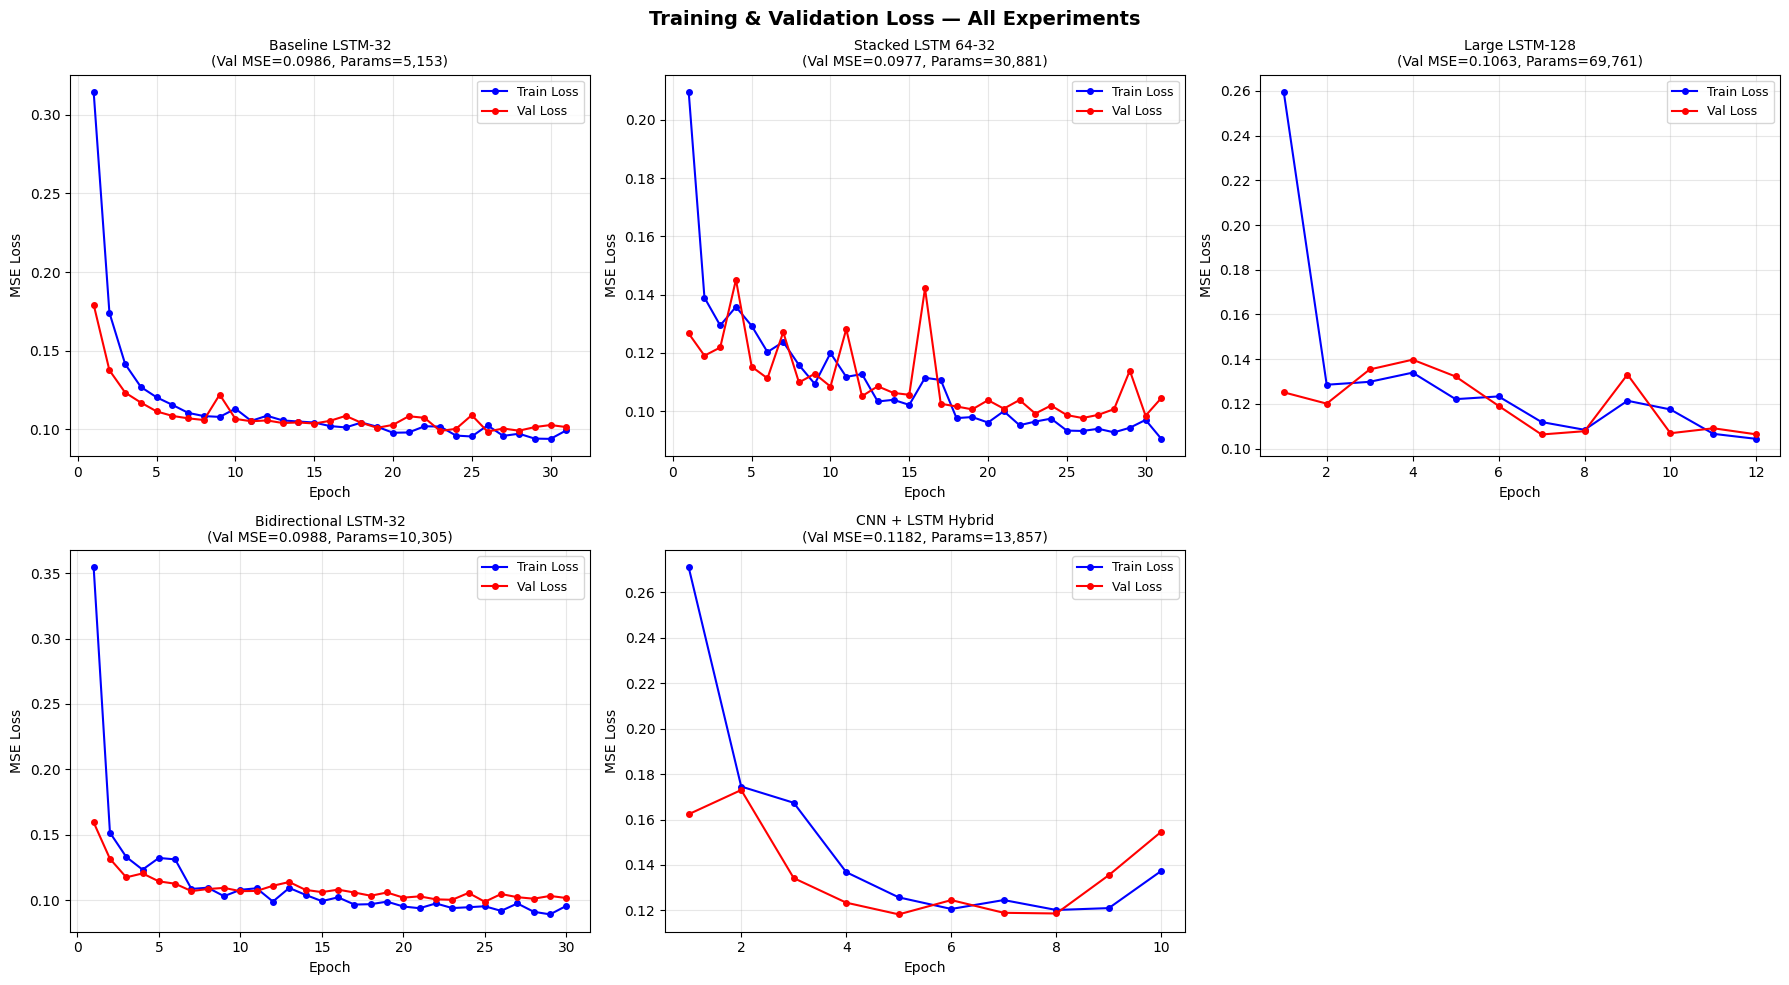

Saved: training_curves.png


In [19]:
n = len(RESULTS)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

for ax, (name, result) in zip(axes, RESULTS.items()):
    hist = result["history"].history
    ep   = range(1, len(hist["loss"]) + 1)
    ax.plot(ep, hist["loss"],     "b-o", markersize=4, label="Train Loss")
    ax.plot(ep, hist["val_loss"], "r-o", markersize=4, label="Val Loss")
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    m = RESULTS[name]["metrics"]
    ax.set_title(f"{name}\n(Val MSE={m['MSE']:.4f}, Params={m['params']:,})",
                 fontsize=10)
# Hide any unused axes
for ax in axes[len(RESULTS):]:
    ax.set_visible(False)

plt.suptitle("Training & Validation Loss — All Experiments", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: training_curves.png")